In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load & Understand Your Data

In [3]:
df = pd.read_csv('./train.csv')
df.sample()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
170,171,0,1,"Van der hoef, Mr. Wyckoff",male,61.0,0,0,111240,33.5,B19,S


In [4]:
# Understand The shape

print('Rowns & Columns:', df.shape)
print()
print('Column Names: ' , df.columns.tolist())

Rowns & Columns: (891, 12)

Column Names:  ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [5]:
# Check Missing Values
print('Missing Values:')
print(df.isnull().sum())
print()
print("Missing Percentage:")
print((df.isnull().sum()/ len(df)* 100).round(2) )

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing Percentage:
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64


## Data Visualization

## Survival Rate Overview

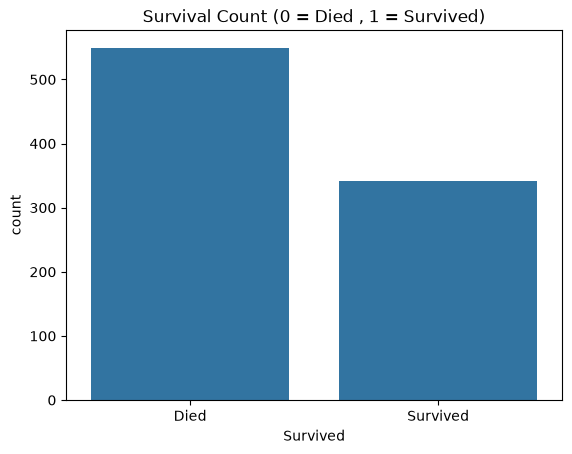

Survived
0    549
1    342
Name: count, dtype: int64

Survival Rate: 38.38 %


In [6]:
# Survival Rate Overview

sns.countplot(x='Survived', data=df)
plt.title('Survival Count (0 = Died , 1 = Survived)')
plt.xticks ([0,1],['Died','Survived'])
plt.show()

print(df['Survived'].value_counts())
print()
print("Survival Rate:", (df['Survived'].mean() * 100).round(2),'%')

# Survival By Gender

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


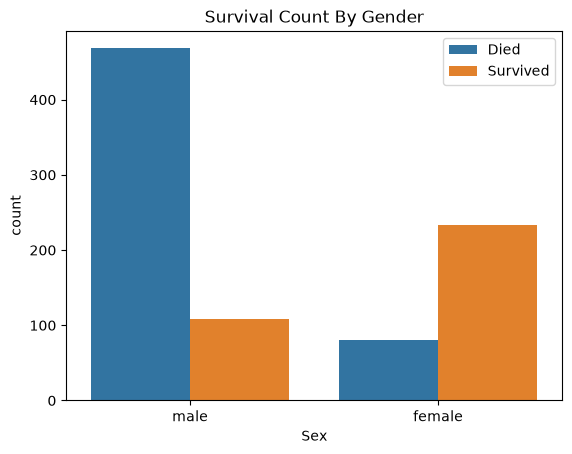

In [7]:
# Survival By Gender
sns.countplot(x='Sex',hue='Survived', data =df)
plt.title('Survival Count By Gender')
plt.legend(['Died', 'Survived'])
plt.show

print(df.groupby('Sex')['Survived'].mean() * 100)

# Survival By Passenger Class

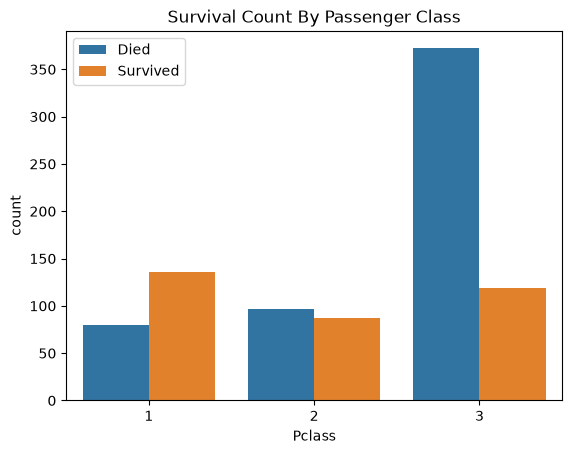

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


In [8]:
# Survival By Passenger Class

sns.countplot(x='Pclass', hue='Survived',data=df)
plt.title('Survival Count By Passenger Class')
plt.legend(['Died','Survived'])
plt.show()

print(df.groupby('Pclass')['Survived'].mean() * 100)

# Survival By Age

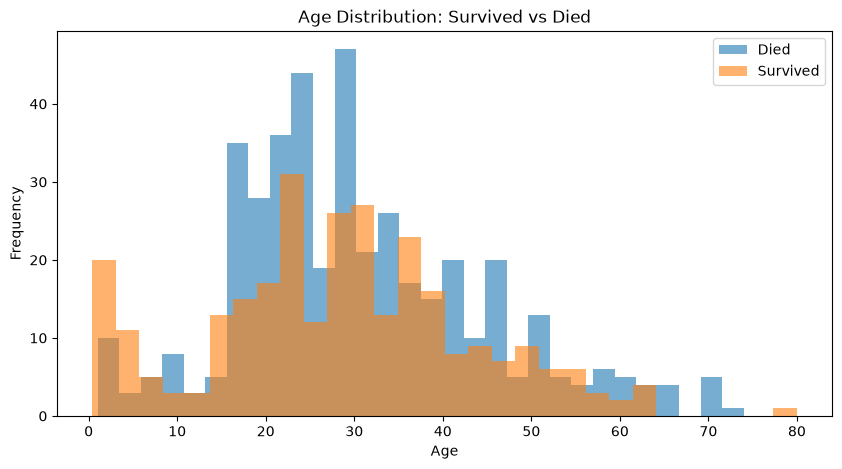

Average age of survivors: 28.34
Average age of those who die: 30.63


In [9]:
# Survival By Age

plt.figure(figsize=(10,5))

df[df['Survived'] == 0]['Age'].plot(kind='hist',alpha =0.6 , label='Died',bins=30)
df[df['Survived']==1]['Age'].plot(kind='hist',alpha=0.6 , label='Survived',bins=30)

plt.title('Age Distribution: Survived vs Died')
plt.xlabel('Age')
plt.legend()
plt.show()

print('Average age of survivors:', df[df['Survived']==1]['Age'].mean().round(2))
print('Average age of those who die:',df[df["Survived"]==0]['Age'].mean().round(2))



## Survival. By Fare

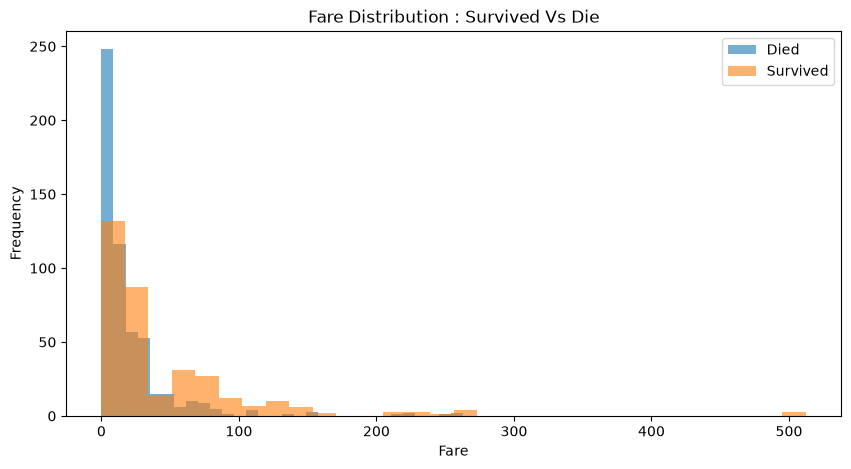

Average fare of survivor : 48.4
Average fare of those who died: 22.12


In [10]:
plt.figure(figsize =(10,5))

df[df['Survived']==0]['Fare'].plot(kind='hist',alpha=0.6 , label='Died',bins=30)
df[df['Survived']==1]['Fare'].plot(kind='hist',alpha=0.6 , label='Survived',bins=30)

plt.title('Fare Distribution : Survived Vs Die')
plt.xlabel('Fare')
plt.legend()
plt.show()

print('Average fare of survivor :',df[df['Survived']==1]['Fare'].mean().round(2))
print('Average fare of those who died:' , df[df['Survived']==0]['Fare'].mean().round(2))

### Combine SibSp and Parch into one Family Size column

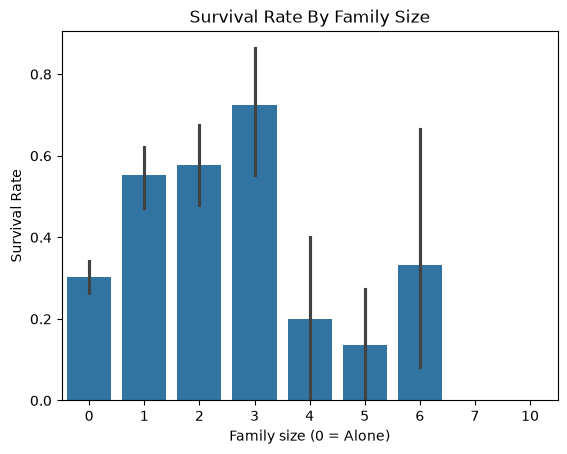

FamilySize
0     30.353818
1     55.279503
2     57.843137
3     72.413793
4     20.000000
5     13.636364
6     33.333333
7      0.000000
10     0.000000
Name: Survived, dtype: float64


In [11]:
df['FamilySize'] = df['SibSp'] + df['Parch']

sns.barplot(x='FamilySize',y='Survived', data=df)

plt.title('Survival Rate By Family Size')
plt.xlabel('Family size (0 = Alone)')
plt.ylabel('Survival Rate')
plt.show()

print(df.groupby('FamilySize')['Survived'].mean() * 100)

# Survival By Embarked

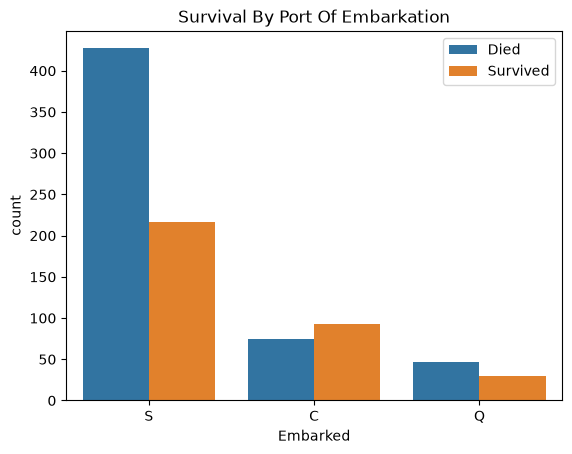

Embarked
C    55.357143
Q    38.961039
S    33.695652
Name: Survived, dtype: float64


In [12]:
sns.countplot(x ='Embarked', hue='Survived',data=df)

plt.title('Survival By Port Of Embarkation')
plt.legend(['Died','Survived'])
plt.show()

print(df.groupby('Embarked')['Survived'].mean() * 100)

# Drop Cabin

In [13]:
df = df.drop(columns=['Cabin'])
print('Columns Remaining:', df.columns.tolist())

Columns Remaining: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize']


# Fix Embarked

In [14]:
# Find the most common port
print('Most common port:',df['Embarked'].mode()[0])

# fill missing values with it
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

#Verify no more missing
print('Missing Embarked:', df['Embarked'].isnull().sum())

Most common port: S
Missing Embarked: 0


# Fix Age

In [15]:
# Check Median Age
print('Median Age:', df['Age'].median())

# Fill missing values with median
df['Age'] = df['Age'].fillna(df['Age'].median())

#Verify no more missing
print('Missing Age:',df['Age'].isnull().sum())

Median Age: 28.0
Missing Age: 0


# Extrat Titles From Name

In [16]:
# Extract title from name
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# See what titles exist
print(df['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


# Simplify Titles

In [17]:
# Group rare titles
df['Title'] = df['Title'].replace(
    ['Dr', 'Rev', 'Mlle', 'Major', 'Col', 'Countess', 
     'Capt', 'Ms', 'Sir', 'Lady', 'Mme', 'Don', 'Jonkheer'], 
    'Rare'
)

#verify
print(df['Title'].value_counts())
print()

#See survival rate by title
print(df.groupby('Title')['Survived'].mean()*100)

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

Title
Master    57.500000
Miss      69.780220
Mr        15.667311
Mrs       79.200000
Rare      44.444444
Name: Survived, dtype: float64


# Drop Useless Column

In [18]:
df = df.drop(columns=['PassengerId','Name','Ticket','SibSp','Parch'])
print("Remaining columns:",df.columns.tolist())

Remaining columns: ['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'Title']


## Encode Categorical Columns

In [19]:
df = pd.get_dummies(df,columns=['Sex','Embarked','Title'],drop_first=True)

print(df.columns.tolist())
print()
print(df.head())

['Survived', 'Pclass', 'Age', 'Fare', 'FamilySize', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']

   Survived  Pclass   Age     Fare  FamilySize  Sex_male  Embarked_Q  \
0         0       3  22.0   7.2500           1      True       False   
1         1       1  38.0  71.2833           1     False       False   
2         1       3  26.0   7.9250           0     False       False   
3         1       1  35.0  53.1000           1     False       False   
4         0       3  35.0   8.0500           0      True       False   

   Embarked_S  Title_Miss  Title_Mr  Title_Mrs  Title_Rare  
0        True       False      True      False       False  
1       False       False     False       True       False  
2        True        True     False      False       False  
3        True       False     False       True       False  
4        True       False      True      False       False  


## Fix True/False to 1/0

In [20]:
df = df.astype({col: int for col in df.select_dtypes(bool).columns})

print(df.head())

   Survived  Pclass   Age     Fare  FamilySize  Sex_male  Embarked_Q  \
0         0       3  22.0   7.2500           1         1           0   
1         1       1  38.0  71.2833           1         0           0   
2         1       3  26.0   7.9250           0         0           0   
3         1       1  35.0  53.1000           1         0           0   
4         0       3  35.0   8.0500           0         1           0   

   Embarked_S  Title_Miss  Title_Mr  Title_Mrs  Title_Rare  
0           1           0         1          0           0  
1           0           0         0          1           0  
2           1           1         0          0           0  
3           1           0         0          1           0  
4           1           0         1          0           0  


# Final Check

In [21]:
print("Shape:", df.shape)
print()
print("Total Missing Values:", df.isnull().sum().sum())
print()
print("Data Types:")
print(df.dtypes)

Shape: (891, 12)

Total Missing Values: 0

Data Types:
Survived        int64
Pclass          int64
Age           float64
Fare          float64
FamilySize      int64
Sex_male        int64
Embarked_Q      int64
Embarked_S      int64
Title_Miss      int64
Title_Mr        int64
Title_Mrs       int64
Title_Rare      int64
dtype: object


In [22]:
df.head()

,Survived,Pclass,Age,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,22.0,7.2500,1,1,0,1,0,1,0,0
1,1,1,38.0,71.2833,1,0,0,0,0,0,1,0
2,1,3,26.0,7.9250,0,0,0,1,1,0,0,0
3,1,1,35.0,53.1000,1,0,0,1,0,0,1,0
4,0,3,35.0,8.0500,0,1,0,1,0,1,0,0


# TRAINING MODEL

Split X and Y

In [23]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Survived'])
y = df['Survived']

X_train , X_test , y_train , y_test = train_test_split(X,y , test_size =0.2 , random_state=42)

print(X_train.shape)
print(X_test.shape)


(712, 11)
(179, 11)


Train

In [24]:
from sklearn.linear_model import LogisticRegression

logistic = LogisticRegression(max_iter=1000)
logistic.fit(X_train, y_train)
y_pred = logistic.predict(X_test)

Evaluate

In [25]:
from sklearn.metrics import accuracy_score ,confusion_matrix ,classification_report

print('Accuracy', accuracy_score(y_test , y_pred))
print('Confusion', confusion_matrix(y_test,y_pred))
print('Classification',classification_report(y_test, y_pred))

Accuracy 0.7932960893854749
Confusion [[87 18]
 [19 55]]
Classification               precision    recall  f1-score   support

           0       0.82      0.83      0.82       105
           1       0.75      0.74      0.75        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179



# Decision Tree

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report , confusion_matrix

tree_clf = DecisionTreeClassifier()
tree_clf.fit(X_train,y_train)
y_pred = tree_clf.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[87 18]
 [19 55]]
              precision    recall  f1-score   support

           0       0.82      0.83      0.82       105
           1       0.75      0.74      0.75        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179



In [27]:
from sklearn.model_selection import GridSearchCV

params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(DecisionTreeClassifier(), params, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
y_pred_grid = grid.predict(X_test)
print(classification_report(y_test, y_pred_grid))

Best params: {'criterion': 'gini', 'max_depth': 6, 'min_samples_split': 10}
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.84      0.69      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179



RANDOM FOREST

In [28]:
from sklearn.ensemble import RandomForestClassifier

randF = RandomForestClassifier()
randF.fit(X_train, y_train)
y_pred = randF.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[89 16]
 [14 60]]
              precision    recall  f1-score   support

           0       0.86      0.85      0.86       105
           1       0.79      0.81      0.80        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179



In [29]:
from xgboost import XGBClassifier

xgbc = XGBClassifier(n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42)
xgbc.fit(X_train, y_train)
y_pred = xgbc.predict(X_test)

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[92 13]
 [15 59]]
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       105
           1       0.82      0.80      0.81        74

    accuracy                           0.84       179
   macro avg       0.84      0.84      0.84       179
weighted avg       0.84      0.84      0.84       179



In [30]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
print(classification_report(y_test, knn.predict(X_test)))

# Naive Bayes
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)
print(classification_report(y_test, nb.predict(X_test)))

# SVM
from sklearn.svm import SVC
svc = SVC()
svc.fit(X_train, y_train)
print(classification_report(y_test, svc.predict(X_test)))

              precision    recall  f1-score   support

           0       0.72      0.88      0.79       105
           1       0.75      0.53      0.62        74

    accuracy                           0.73       179
   macro avg       0.74      0.70      0.71       179
weighted avg       0.73      0.73      0.72       179

              precision    recall  f1-score   support

           0       0.81      0.79      0.80       105
           1       0.71      0.73      0.72        74

    accuracy                           0.77       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179

              precision    recall  f1-score   support

           0       0.64      0.94      0.76       105
           1       0.76      0.26      0.38        74

    accuracy                           0.66       179
   macro avg       0.70      0.60      0.57       179
weighted avg       0.69      0.66      0.61       179



### SAVE PKL

In [31]:
joblib.dump(randF,'titanic_model.pkl')
print('Model Saved')

Model Saved
